In [ ]:
import pandas as pd

Total_population = 0
def process_data():
    data = pd.read_csv(
        "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv",
        parse_dates=["date"]
    )

    data["Cumulative_Recovered"] = (
        data["cumulative_confirmed"].shift(14).fillna(0)
        - data["cumulative_deceased"]
    )
    data["new_recovered"] = data["Cumulative_Recovered"].diff().clip(lower=0)

    columns = [
        "date", "new_confirmed", "new_deceased", "new_recovered",
        "new_hospitalized_patients", "current_hospitalized_patients",
        "stringency_index"
    ]
    df = data[columns].copy()

    flows = ["new_confirmed", "new_deceased", "new_recovered",
             "new_hospitalized_patients"]
    df[flows] = df[flows].mask(df[flows] < 0, 0)

    df["cum_confirmed"]   = df["new_confirmed"].cumsum()
    df["cum_deceased"]    = df["new_deceased"].cumsum()
    df["cum_recovered"]   = df["new_recovered"].cumsum()

    if df["current_hospitalized_patients"].notna().any():
        df["hospitalized"] = (
            df["current_hospitalized_patients"]
            .fillna(method="ffill")
            .fillna(0)
        )
    else:
        LOS = 8
        df["hospitalized"] = (
            df["new_hospitalized_patients"]
            .rolling(LOS, min_periods=1)
            .sum()
        )

    df["infected_non_hosp"] = (
        df["cum_confirmed"]
        - df["cum_recovered"]
        - df["cum_deceased"]
    ).clip(lower=0)

    N = data["population"].iloc[0]
    global Total_population
    Total_population = N
    df["susceptible"] = (
        N
        - df["infected_non_hosp"]
        - df["hospitalized"]
        - df["cum_recovered"]
        - df["cum_deceased"]
    ).clip(lower=0)

    df.rename(columns={
        "infected_non_hosp": "active_infected",
        "cum_deceased":      "deaths",
        "cum_recovered":     "recovered"
    }, inplace=True)

    return df


In [ ]:
filtered_data = process_data()

<ipython-input-198-68a909644ff4>:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


In [ ]:
import numpy as np

I_all = filtered_data['active_infected'].values
H_all = filtered_data['hospitalized'].values
R_all = filtered_data['recovered'].values
D_all = filtered_data['deaths'].values
S_all = filtered_data['susceptible'].values
t_all = np.arange(len(I_all))



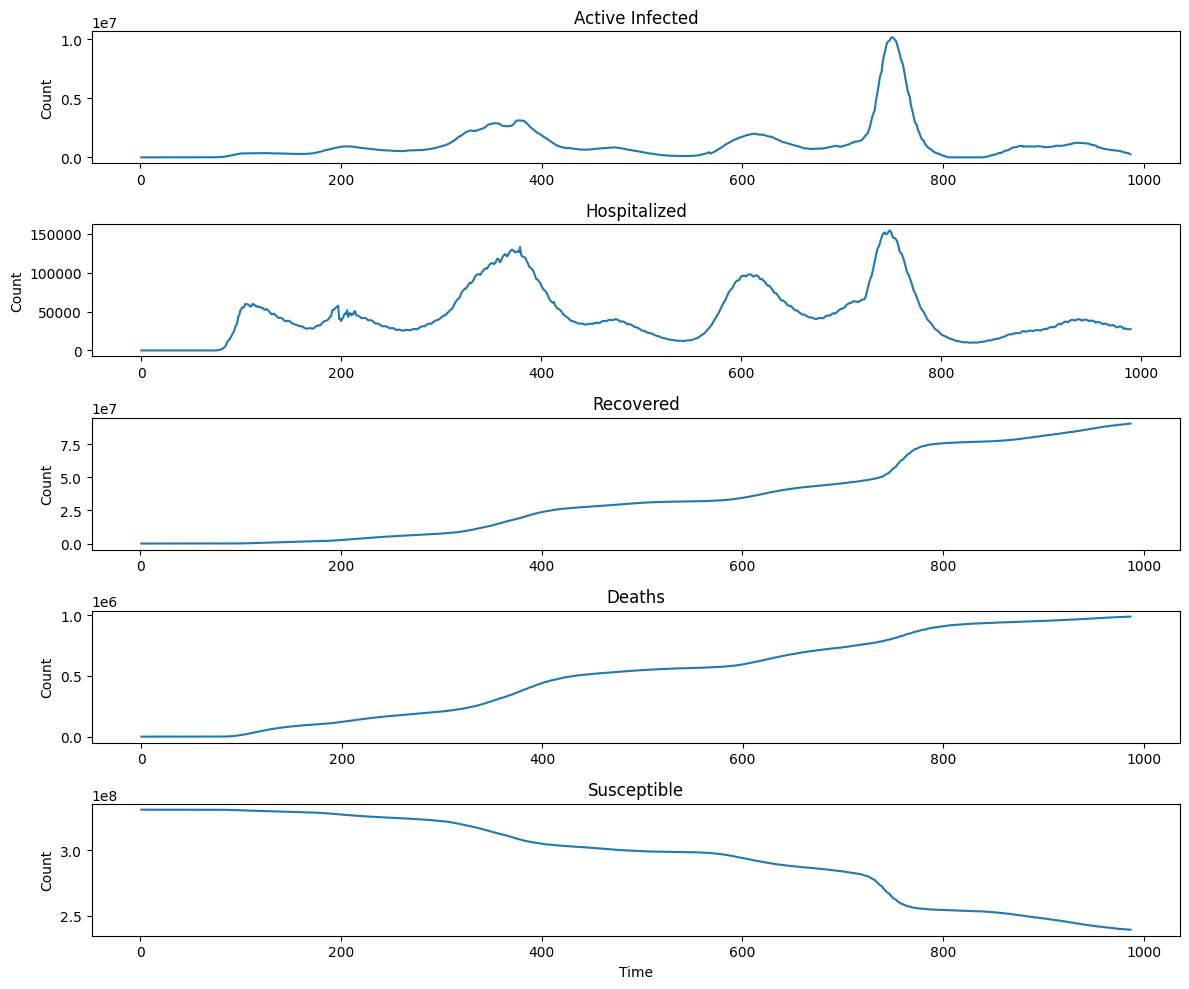

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_all, I_all)
plt.title('Active Infected')
plt.ylabel('Count')

plt.subplot(5, 1, 2)
plt.plot(t_all, H_all)
plt.title('Hospitalized')
plt.ylabel('Count')

plt.subplot(5, 1, 3)
plt.plot(t_all, R_all)
plt.title('Recovered')
plt.ylabel('Count')

plt.subplot(5, 1, 4)
plt.plot(t_all, D_all)
plt.title('Deaths')
plt.ylabel('Count')

plt.subplot(5, 1, 5)
plt.plot(t_all, S_all)
plt.title('Susceptible')
plt.xlabel('Time')
plt.ylabel('Count')

plt.tight_layout()

plt.show()


In [ ]:
def SIRDH(y, t, beta, gamma, delta, rho, mu, zeta, eta):
    S, I, H, R, D = y
    N = S + I + H + R

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - (gamma + delta + zeta) * I
    dHdt = delta * I - (rho + mu) * H
    dRdt = gamma * I + rho * H
    dDdt = mu * H + zeta * I

    return [dSdt, dIdt, dHdt, dRdt, dDdt]


In [ ]:
train_start = 700
train_end = 800

t_train = t_all[train_start:train_end]
I_train = I_all[train_start:train_end]
H_train = H_all[train_start:train_end]
R_train = R_all[train_start:train_end]
D_train = D_all[train_start:train_end]
S_train = S_all[train_start:train_end]

Text(0, 0.5, 'Count')

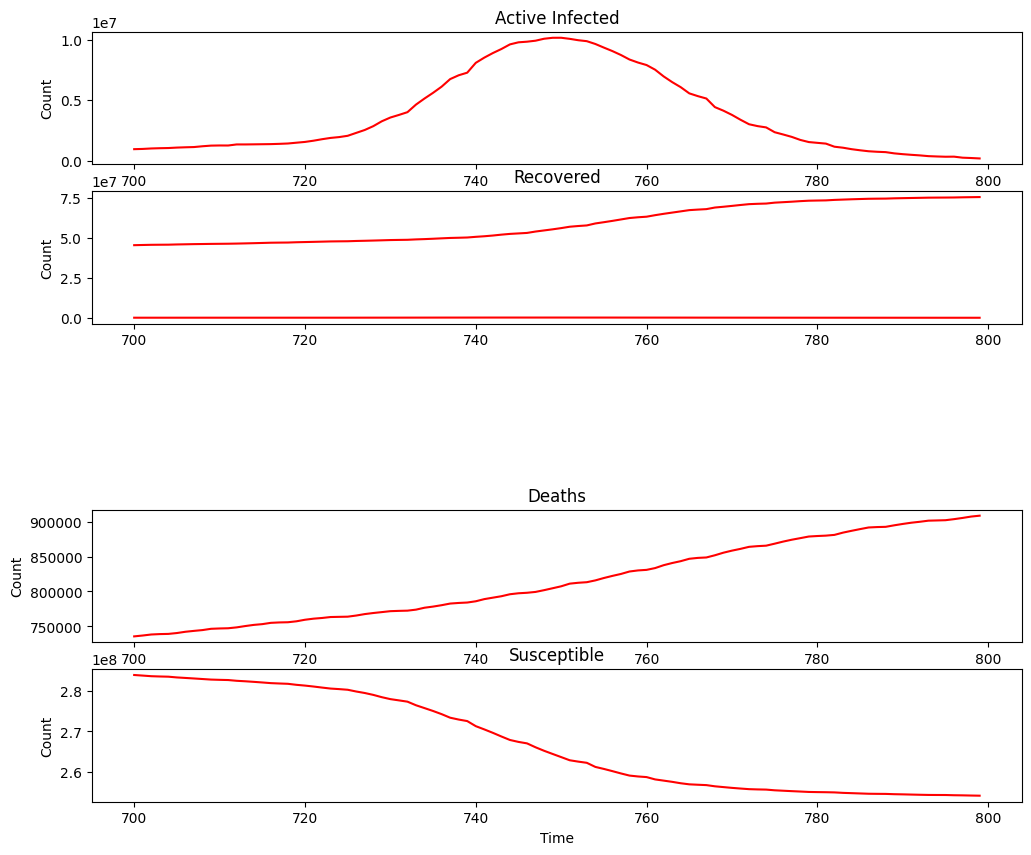

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_train, I_train, color = "r")
plt.title('Active Infected')
plt.ylabel('Count')

plt.subplot(5, 1, 2)
plt.plot(t_train, H_train,  color = "r")
plt.title('Hospitalized')
plt.ylabel('Count')

plt.plot(t_train, R_train,  color = "r")
plt.title('Recovered')
plt.ylabel('Count')

plt.subplot(5, 1, 4)
plt.plot(t_train, D_train,  color = "r")
plt.title('Deaths')
plt.ylabel('Count')

plt.subplot(5, 1, 5)
plt.plot(t_train, S_train,  color = "r")
plt.title('Susceptible')
plt.xlabel('Time')
plt.ylabel('Count')

In [ ]:
!pip install pysindy

In [ ]:
import numpy as np
import pysindy as ps

X = np.column_stack([
    S_train,
    I_train,
    H_train,
    R_train,
    D_train
])

X = X/Total_population

In [ ]:
t = t_train
dt = t[1] - t[0]

In [ ]:
import numpy as np
t = filtered_data.index.values

xdot = np.zeros_like(X)
xdot[1:-1] = (X[2:] - X[:-2]) / 2
print(len(xdot))

xdot[0] = X[1] - X[0]
print(len(xdot))

xdot[-1] = X[-1] - X[-2]
print(len(xdot))

100
100
100


In [ ]:
xdot[0], xdot[1]

(array([-4.30528279e-04,  6.00720272e-05,  8.33830190e-07,  3.65891334e-04,
         3.73108799e-06]),
 array([-4.45884652e-04,  8.75476383e-05,  1.63291746e-06,  3.52625579e-04,
         4.07851723e-06]))

In [ ]:
poly_lib  = ps.PolynomialLibrary(degree=2, include_bias=True)
stlsq_opt = ps.STLSQ(threshold=0.00025)

Text(0, 0.5, 'Count')

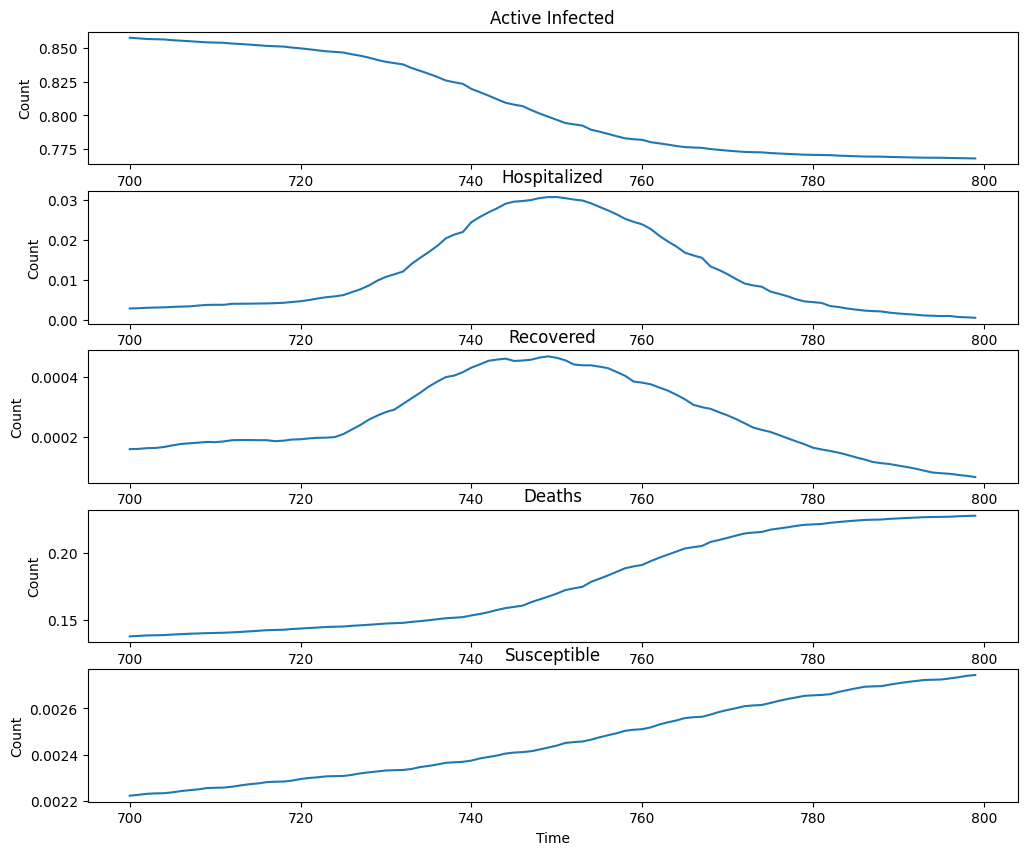

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_train, X[:, 0])
plt.title('Active Infected')
plt.ylabel('Count')

plt.subplot(5, 1, 2)
plt.plot(t_train, X[:, 1])
plt.title('Hospitalized')
plt.ylabel('Count')

plt.subplot(5, 1, 3)
plt.plot(t_train, X[:, 2])
plt.title('Recovered')
plt.ylabel('Count')

plt.subplot(5, 1, 4)
plt.plot(t_train, X[:, 3])
plt.title('Deaths')
plt.ylabel('Count')

plt.subplot(5, 1, 5)
plt.plot(t_train, X[:, 4])
plt.title('Susceptible')
plt.xlabel('Time')
plt.ylabel('Count')

In [ ]:
model = ps.SINDy(
    optimizer=stlsq_opt,
    feature_library=poly_lib,
    feature_names=["S", "I", "H", "R", "D"]
)

model.fit(X, t=t_train, x_dot=xdot)
model.print()


(S)' = -170086.638 1 + 340791.552 S + 344507.464 I + 342199.376 R + -170705.447 S^2 + -345133.510 S I + -342821.628 S R + -174451.564 I^2 + -346559.243 I R + -172118.112 R^2
(I)' = -2.451 1 + 3.226 S + 2.213 R + -0.781 S^2 + 2.383 S I + -0.448 S R + 0.105 R^2
(H)' = 0.000
(R)' = 24739.329 1 + -49595.178 S + -49856.567 I + -49587.082 R + 24855.967 S^2 + 49973.530 S I + 49704.090 S R + 25121.325 I^2 + 49967.054 I R + 24847.184 R^2
(D)' = 0.000


/usr/local/lib/python3.11/dist-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.00025) and eliminated all coefficients
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysindy/optimizers/stlsq.py:201: UserWarning: Sparsity parameter is too big (0.00025) and eliminated all coefficients
  warnings.warn(


In [ ]:
x0     = X[0]
t_sim  = np.linspace(0, (len(t_train)-1)*dt, len(t_train))
X_pred = model.simulate(x0, t_sim)

# SINDy diverging and not giving results

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_


ValueError: Input contains infinity or a value too large for dtype('float64').

Text(0, 0.5, 'Count')

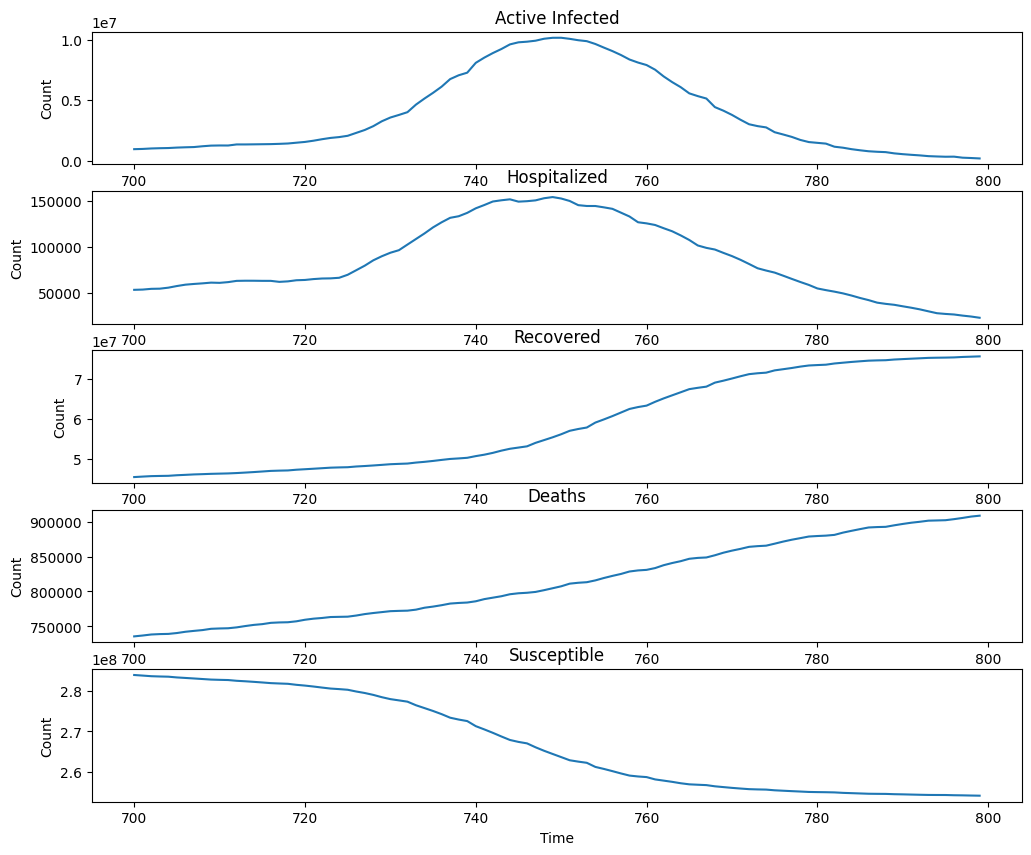

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_train, I_train)
plt.title('Active Infected')
plt.ylabel('Count')

plt.subplot(5, 1, 2)
plt.plot(t_train, H_train)
plt.title('Hospitalized')
plt.ylabel('Count')

plt.subplot(5, 1, 3)
plt.plot(t_train, R_train)
plt.title('Recovered')
plt.ylabel('Count')

plt.subplot(5, 1, 4)
plt.plot(t_train, D_train)
plt.title('Deaths')
plt.ylabel('Count')

plt.subplot(5, 1, 5)
plt.plot(t_train, S_train)
plt.title('Susceptible')
plt.xlabel('Time')
plt.ylabel('Count')

In [ ]:
from scipy.optimize import minimize
from scipy.integrate import odeint

def loss(params):
    beta, gamma, delta, rho, mu, zeta, eta = params
    y0 = [S_train[0], I_train[0], H_train[0], R_train[0], D_train[0]]
    solution = odeint(SIRDH, y0, t_train - t_train[0], args=(beta, gamma, delta, rho, mu, zeta, eta))
    S_pred, I_pred, H_pred, R_pred, D_pred = solution.T

    error_I = 7*np.sum(abs((I_pred - I_train)/I_train.max()))
    error_H = np.sum(abs((H_pred - H_train)/H_train.max()))
    error_R = np.sum(abs((R_pred - R_train)/R_train.max()))
    error_D = np.sum(abs((D_pred - D_train)/D_train.max()))
    error_S = np.sum(abs((S_pred - S_train)/S_train.max()))

    total_loss = error_I + error_H + error_R + error_D + error_S
    return total_loss

params_initial = [0.9, 0.05, 0.05, 0.05, 0.1, 0.1, 0.2]
result = minimize(loss, params_initial, bounds=[(-1, 1)]*7, method='L-BFGS-B')
beta_fit, gamma_fit, delta_fit, rho_fit, mu_fit, zeta_fit, eta_fit = result.x

print("Fitted parameters on training chunk:")
print(f"Beta: {beta_fit:.4f}, Gamma: {gamma_fit:.4f}, Delta: {delta_fit:.4f}, Rho: {rho_fit:.4f}, Mu: {mu_fit:.4f}, Zeta: {zeta_fit:.4f}, eta: {eta_fit:.4f}")



Fitted parameters on training chunk:
Beta: 0.3864, Gamma: 0.2502, Delta: 0.0136, Rho: 0.6184, Mu: 0.0847, Zeta: -0.0013, eta: 0.2000


In [ ]:
from sklearn.metrics import mean_squared_error

test_start = 700
test_end = test_start + 100

t_test = t_all[test_start:test_end]
I_test = I_all[test_start:test_end]
H_test = H_all[test_start:test_end]
R_test = R_all[test_start:test_end]
D_test = D_all[test_start:test_end]
S_test = S_all[test_start:test_end]



Text(0, 0.5, 'Count')

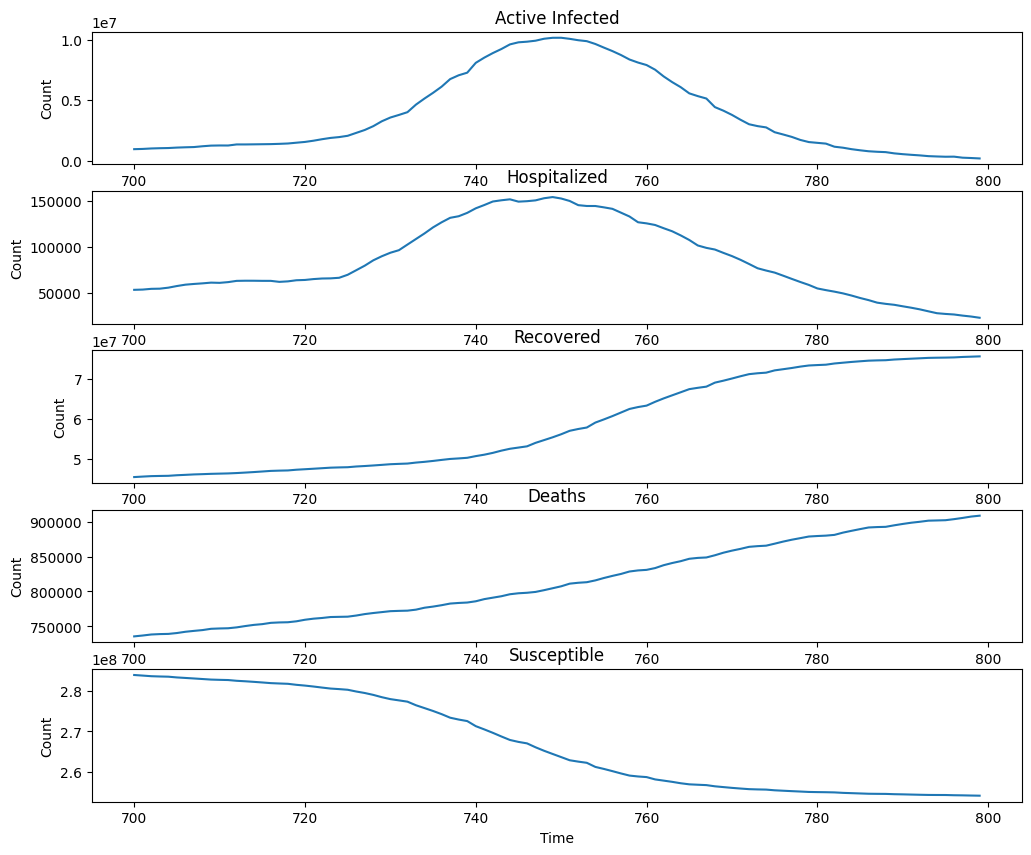

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_test, I_test)
plt.title('Active Infected')
plt.ylabel('Count')

plt.subplot(5, 1, 2)
plt.plot(t_test, H_test)
plt.title('Hospitalized')
plt.ylabel('Count')

plt.subplot(5, 1, 3)
plt.plot(t_test, R_test)
plt.title('Recovered')
plt.ylabel('Count')

plt.subplot(5, 1, 4)
plt.plot(t_test, D_test)
plt.title('Deaths')
plt.ylabel('Count')

plt.subplot(5, 1, 5)
plt.plot(t_test, S_test)
plt.title('Susceptible')
plt.xlabel('Time')
plt.ylabel('Count')

In [ ]:

y0_test = [S_train[0], I_train[0], H_train[0], R_train[0], D_train[0]]

solution_test = odeint(SIRDH, y0_test, t_test - t_test[0], args=(beta_fit, gamma_fit, delta_fit, rho_fit, mu_fit, zeta_fit, eta_fit))
S_pred_test, I_pred_test, H_pred_test, R_pred_test, D_pred_test = solution_test.T


In [ ]:

mseI = mean_squared_error(I_test, I_pred_test)
mseH = mean_squared_error(H_test, H_pred_test)
mseR = mean_squared_error(R_test, R_pred_test)
mseD = mean_squared_error(D_test, D_pred_test)
mseS = mean_squared_error(S_test, S_pred_test)

print("Mean Squared Error Infected:", mseI)
print("Mean Squared Error Hospitalized:", mseH)
print("Mean Squared Error Recovered:", mseR)
print("Mean Squared Error Deaths:", mseD)
print("Mean Squared Error Susceptible:", mseS)

Mean Squared Error Infected: 2077457793132.3972
Mean Squared Error Hospitalized: 134236297.18881017
Mean Squared Error Recovered: 2556109773645435.0
Mean Squared Error Deaths: 34985308.25610092
Mean Squared Error Susceptible: 2577037769968280.5


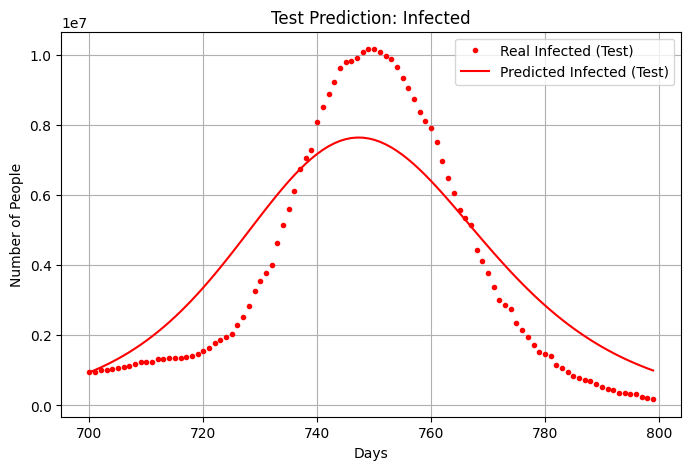

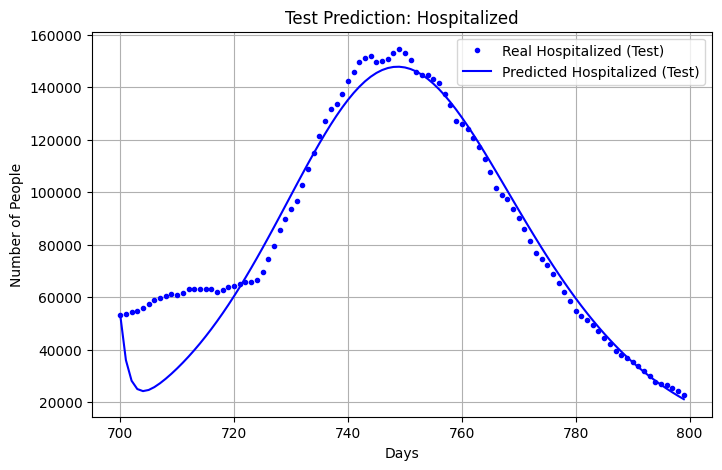

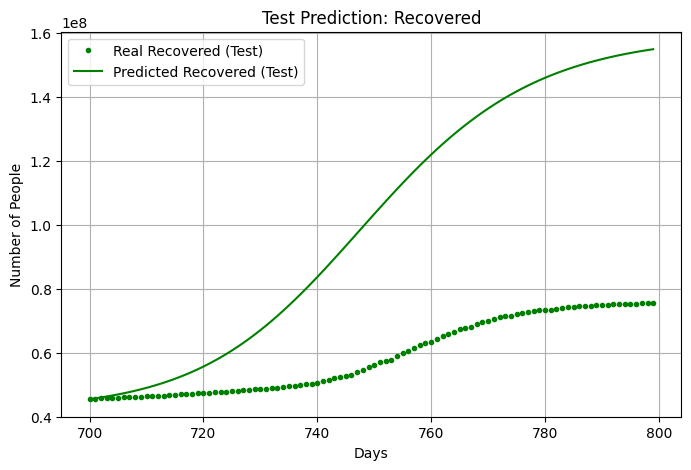

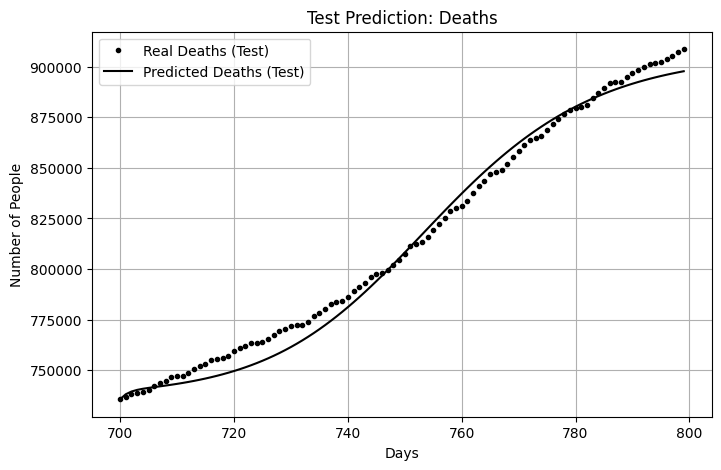

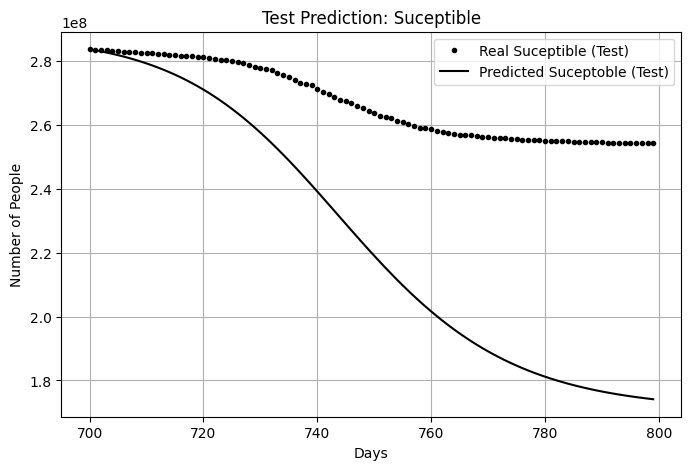

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(t_test, I_test, 'r.', label='Real Infected (Test)')
plt.plot(t_test, I_pred_test, 'r-', label='Predicted Infected (Test)')
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Test Prediction: Infected')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_test, H_test, 'b.', label='Real Hospitalized (Test)')
plt.plot(t_test, H_pred_test, 'b-', label='Predicted Hospitalized (Test)')
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Test Prediction: Hospitalized')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_test, R_test, 'g.', label='Real Recovered (Test)')
plt.plot(t_test, R_pred_test, 'g-', label='Predicted Recovered (Test)')
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Test Prediction: Recovered')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_test, D_test, 'k.', label='Real Deaths (Test)')
plt.plot(t_test, D_pred_test, 'k-', label='Predicted Deaths (Test)')
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Test Prediction: Deaths')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_test, S_test, 'k.', label='Real Suceptible (Test)')
plt.plot(t_test, S_pred_test, 'k-', label='Predicted Suceptoble (Test)')
plt.xlabel('Days')
plt.ylabel('Number of People')
plt.title('Test Prediction: Suceptible')
plt.legend()
plt.grid()
plt.show()


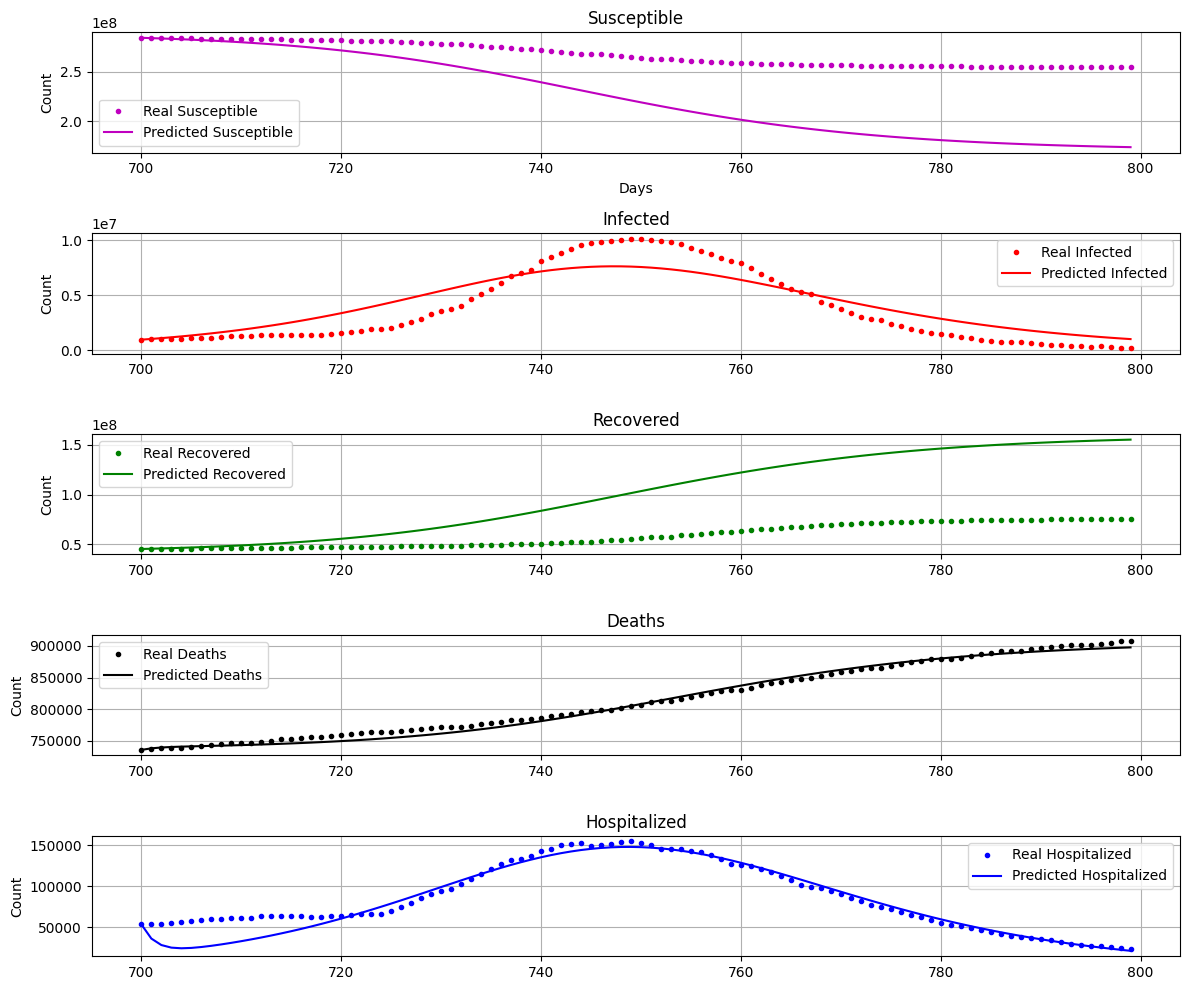

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 2)
plt.plot(t_test, I_test, 'r.', label='Real Infected')
plt.plot(t_test, I_pred_test, 'r-', label='Predicted Infected')
plt.title('Infected')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 5)
plt.plot(t_test, H_test, 'b.', label='Real Hospitalized')
plt.plot(t_test, H_pred_test, 'b-', label='Predicted Hospitalized')
plt.title('Hospitalized')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 3)
plt.plot(t_test, R_test, 'g.', label='Real Recovered')
plt.plot(t_test, R_pred_test, 'g-', label='Predicted Recovered')
plt.title('Recovered')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 4)
plt.plot(t_test, D_test, 'k.', label='Real Deaths')
plt.plot(t_test, D_pred_test, 'k-', label='Predicted Deaths')
plt.title('Deaths')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 1)
plt.plot(t_test, S_test, 'm.', label='Real Susceptible')
plt.plot(t_test, S_pred_test, 'm-', label='Predicted Susceptible')
plt.title('Susceptible')
plt.xlabel('Days')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


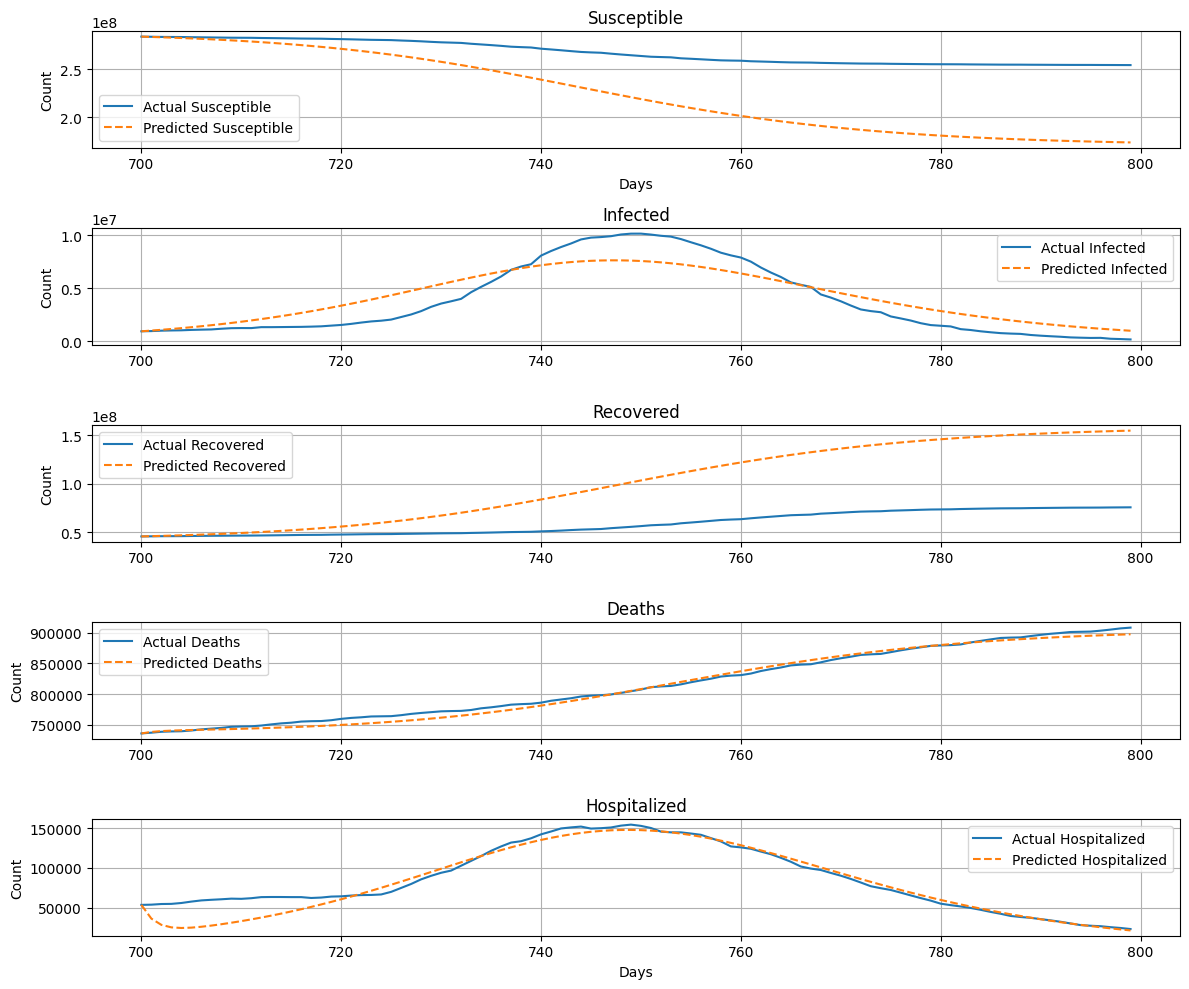

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t_test, S_test, label='Actual Susceptible')
plt.plot(t_test, S_pred_test, linestyle='--', label='Predicted Susceptible')
plt.title('Susceptible')
plt.xlabel('Days')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 2)
plt.plot(t_test, I_test, label='Actual Infected')
plt.plot(t_test, I_pred_test, linestyle='--', label='Predicted Infected')
plt.title('Infected')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 3)
plt.plot(t_test, R_test, label='Actual Recovered')
plt.plot(t_test, R_pred_test, linestyle='--', label='Predicted Recovered')
plt.title('Recovered')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 4)
plt.plot(t_test, D_test, label='Actual Deaths')
plt.plot(t_test, D_pred_test, linestyle='--', label='Predicted Deaths')
plt.title('Deaths')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.subplot(5, 1, 5)
plt.plot(t_test, H_test, label='Actual Hospitalized')
plt.plot(t_test, H_pred_test, linestyle='--', label='Predicted Hospitalized')
plt.title('Hospitalized')
plt.xlabel('Days')
plt.ylabel('Count')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


331002647.0
331002647


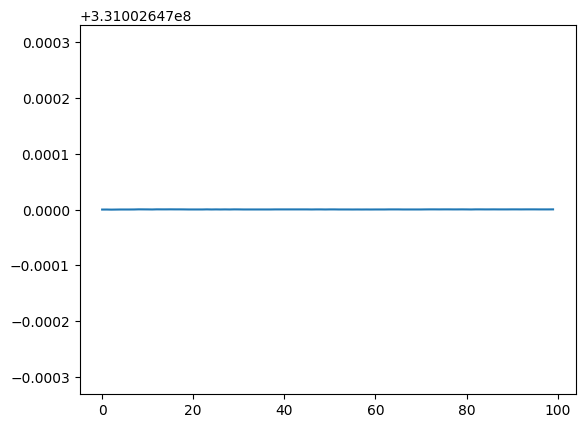

In [ ]:
A1 = np.array(S_pred_test)
A2 = np.array(I_pred_test)
A3 = np.array(H_pred_test)
A4 = np.array(R_pred_test)
A5 = np.array(D_pred_test)

plt.plot(A1+A2+A3+A4+A5)

print((A1+A2+A3+A4+A5)[0])
print(Total_population)